# Deep autoencoder MNIST


A deep autoencoder is a type of artificial neural network used for unsupervised learning to compress, reconstruct, and learn efficient, non-linear representations of data. It consists of deep encoder and decoder networks with a central bottleneck layer, training to minimize reconstruction error between input and output. They are heavily used for dimensionality reduction, denoising, and anomaly detection.

----------------------------------------------------------------

In [1]:
# Import the necessary modules from Keras
# Model: used to define the neural network model
# Input: defines the input layer
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense

# Library for plotting training curves
import matplotlib.pyplot as plt

# Each MNIST image is 28x28 pixels → flattened into a 784-dimensional vector
input_dim = 28*28

# Size of the latent (compressed) representation
latent_vec_dim = 16

# Define input layer for the autoencoder
# Shape = 784 features (flattened image)
input_layer = Input(shape=(input_dim,))

## Encoder

The encoder compresses the input into a lower-dimensional latent space


In [2]:
 # First hidden layer: 500 neurons, sigmoid activation
enc_layer_1 = Dense(500, activation='sigmoid')(input_layer)

# Second hidden layer: 300 neurons
enc_layer_2 = Dense(300, activation='sigmoid')(enc_layer_1)

# Third hidden layer: 100 neurons
enc_layer_3 = Dense(100, activation='sigmoid')(enc_layer_2)

# Latent layer: compressed representation (16 dimensions)
# tanh activation allows values between -1 and 1
enc_layer_4 = Dense(latent_vec_dim, activation='tanh')(enc_layer_3)

# The encoder output is the latent representation
encoder = enc_layer_4

## Decoder

The decoder reconstructs the original image from the latent space

In [3]:
# First decoder layer: expands back to 100 neurons
dec_layer_1 = Dense(100, activation='sigmoid')(encoder)

# Second decoder layer: 300 neurons
dec_layer_2 = Dense(300, activation='sigmoid')(dec_layer_1)

# Third decoder layer: 500 neurons
dec_layer_3 = Dense(500, activation='sigmoid')(dec_layer_2)

# Output layer: reconstructs the original 784-dimensional image
# Sigmoid activation is used because pixel values are normalized between 0 and 1
dec_layer_4 = Dense(input_dim, activation='sigmoid')(dec_layer_3)

# Decoder output
decoder = dec_layer_4

## Autoencoder

In [4]:
# Connect input directly to reconstructed output
autoencoder = Model(input_layer, decoder, name="DeepAE")


# Optional: Model that outputs only the latent representation
# Useful for visualization or feature extraction
latent_model = Model(input_layer, encoder)

# Print model architecture summary
autoencoder.summary()

Model: "DeepAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │         1,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        30,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 500)            │       150,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       392,784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,149,800 (4.39 MB)

 Trainable params: 1,149,800 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

## MNIST

In [5]:
# MNIST dataset contains 28x28 grayscale handwritten digits
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

import numpy as np

# Flatten images from (28, 28) to (784,)
train_images = np.reshape(train_images, (-1, 784))
test_images = np.reshape(test_images, (-1, 784))

# Normalize pixel values from [0, 255] → [0, 1]
# Required for stable training with sigmoid activation
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [6]:
# Binary crossentropy is used because output pixels are between 0 and 1
# Adam optimizer is commonly used for efficient gradient-based optimization
autoencoder.compile(loss='binary_crossentropy', optimizer='adam')


# We train the model to reconstruct its own input
# Input = train_images
# Target = train_images
history = autoencoder.fit(train_images, train_images,
                          epochs=10,
                          batch_size=128,
                          shuffle=True,
                          validation_data=(test_images, test_images))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.2683 - val_loss: 0.2575
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2364 - val_loss: 0.2275
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2219 - val_loss: 0.2153
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2142 - val_loss: 0.2104
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2097 - val_loss: 0.2143
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2072 - val_loss: 0.2042
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2038 - val_loss: 0.2013
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2010 - val_loss: 0.1985
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1986 - val_loss: 0.1976
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1974 - val_loss: 0.1940


## Plot training and validation loss scores


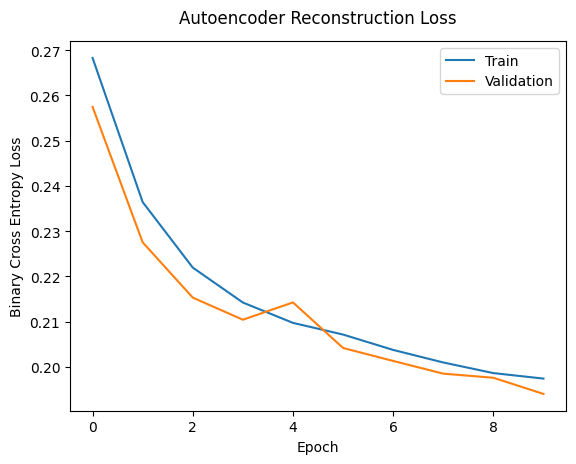

In [7]:
# Plot training and validation loss over epochs
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')

plt.ylabel('Binary Cross Entropy Loss')
plt.xlabel('Epoch')
plt.title('Autoencoder Reconstruction Loss', pad=13)
plt.legend(loc='upper right')